In [1]:
import soundfile as sf
import numpy as np
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

In [2]:
import wave
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
from numpy.lib import stride_tricks
from scipy.io import wavfile
from pydub import AudioSegment

In [39]:
import importlib
import alg1_simple.script1
importlib.reload(alg1_simple.script1)
import alg2_wavelet.script_wavelet
importlib.reload(alg2_wavelet.script_wavelet)
import alg4.script4
importlib.reload(alg4.script4)
import alg5_emd.emd_v2
importlib.reload(alg5_emd.emd_v2)
import alg6_wht.wht_v2
importlib.reload(alg6_wht.wht_v2)

<module 'alg6_wht.wht_v2' from 'E:\\labs\\5 course\\NearS\\measures\\alg6_wht\\wht_v2.py'>

In [4]:
with wave.open("input.wav", "rb") as w:
    nch = w.getnchannels()     # каналы
    sampwidth = w.getsampwidth()  # байт на 1 отсчёт В ОДНОМ КАНАЛЕ
    rate = w.getframerate()
    nframes = w.getnframes()

print("channels =", nch)
print("bytes per sample (per channel) =", sampwidth)
print("bits per sample =", sampwidth * 8)
print("bytes per frame (all channels) =", sampwidth * nch)  # один момент времени
print("frames =", nframes)

channels = 1
bytes per sample (per channel) = 2
bits per sample = 16
bytes per frame (all channels) = 2
frames = 22529


# Загрузка данных

In [5]:
def load_wav(path: str, *, mono: bool = True, dtype="float32"):
    x, sr = sf.read(path, dtype=dtype, always_2d=True)  # shape: (N, C)
    if mono:
        x = x.mean(axis=1)  # (N,)
    else:
        x = x.T  # (C, N) если нужно поканально
    return x, sr

def load_wav_bytes(path: str) -> tuple[int, np.ndarray]:
    fs, data = wavfile.read(path)
    if data.dtype.kind == "f":
        m = np.max(np.abs(data))
        if m > 0:
            data = data / m
        data = (data * 32767.0).astype(np.int16)
    elif data.dtype == np.int32:
        data = (data >> 16).astype(np.int16)
    elif data.dtype == np.uint8:
        data = ((data.astype(np.int16) - 128) << 8).astype(np.int16)
    else:
        data = data.astype(np.int16)
    raw = np.frombuffer(data.tobytes(), dtype=np.uint8)
    return fs, raw

def save_wav_bytes(bytes_: tuple[int, np.ndarray], path: str):
    fs, raw = bytes_
    samples = np.frombuffer(raw.tobytes(), dtype=np.int16)
    wavfile.write(path, fs, samples)

## Энтропия

In [7]:
def entropy(path):
    path = str(path)
    with wave.open(path, "rb") as w:
        data = w.readframes(w.getnframes())
    data = np.frombuffer(data, dtype=np.uint8)
    hist = np.bincount(data, minlength=256)
    p = hist / hist.sum()
    p = p[p>0]
    return -np.sum(p * np.log2(p))

## Корреляция

In [8]:
def correlatioin(first, second):
    first = str(first)
    second = str(second)
    with wave.open(first, "rb") as w:
        first_bytes = w.readframes(w.getnframes())
    with wave.open(second, "rb") as w:
        second_bytes = w.readframes(w.getnframes())
    first = np.frombuffer(first_bytes, dtype=np.uint8).astype(np.float64)
    second = np.frombuffer(second_bytes, dtype=np.uint8).astype(np.float64)
    n = min(first.size, second.size)
    first = first[:n]
    second = second[:n]
    first_exp = first.mean()
    second_exp = second.mean()
    cov = np.mean((first - first_exp) * (second - second_exp))
    first_D = np.mean((first - first_exp)**2)
    second_D = np.mean((second - second_exp)**2)
    return float(cov / ( np.sqrt(first_D) * np.sqrt(second_D) ))


## Спектрограмма

In [9]:
def stft(sig, frameSize, overlapFac=0.5, window=np.hanning):
    win = window(frameSize)
    hopSize = int(frameSize - np.floor(overlapFac * frameSize))

    # zeros at beginning (thus center of 1st window should be for sample nr. 0)   
    samples = np.append(np.zeros(int(np.floor(frameSize/2.0))), sig)    
    # cols for windowing
    cols = np.ceil( (len(samples) - frameSize) / float(hopSize)) + 1
    # zeros at end (thus samples can be fully covered by frames)
    samples = np.append(samples, np.zeros(frameSize))

    frames = stride_tricks.as_strided(samples, shape=(int(cols), frameSize), strides=(samples.strides[0]*hopSize, samples.strides[0])).copy()
    frames *= win

    return np.fft.rfft(frames) 


def logscale_spec(spec, sr=44100, factor=20.):
    timebins, freqbins = np.shape(spec)

    scale = np.linspace(0, 1, freqbins) ** factor
    scale *= (freqbins-1)/max(scale)
    scale = np.unique(np.round(scale))

    # create spectrogram with new freq bins
    newspec = np.complex128(np.zeros([timebins, len(scale)]))
    for i in range(0, len(scale)):        
        if i == len(scale)-1:
            newspec[:,i] = np.sum(spec[:,int(scale[i]):], axis=1)
        else:        
            newspec[:,i] = np.sum(spec[:,int(scale[i]):int(scale[i+1])], axis=1)

    # list center freq of bins
    allfreqs = np.abs(np.fft.fftfreq(freqbins*2, 1./sr)[:freqbins+1])
    freqs = []
    for i in range(0, len(scale)):
        if i == len(scale)-1:
            freqs += [np.mean(allfreqs[int(scale[i]):])]
        else:
            freqs += [np.mean(allfreqs[int(scale[i]):int(scale[i+1])])]

    return newspec, freqs

def spectogram(audiopath, binsize=2**10, plotpath=None, colormap="jet"): #<------THIS ONEEEEEEEEEE
    samplerate, samples = wav.read(audiopath)

    s = stft(samples, binsize)

    sshow, freq = logscale_spec(s, factor=1.0, sr=samplerate)

    ims = 20.*np.log10(np.abs(sshow)/10e-6) # amplitude to decibel

    timebins, freqbins = np.shape(ims)

    print("timebins: ", timebins)
    print("freqbins: ", freqbins)

    plt.figure(figsize=(6, 3))
    plt.imshow(np.transpose(ims), origin="lower", aspect="auto", cmap=colormap, interpolation="none")
    plt.colorbar()
    
    plt.xlabel("time (s)")
    plt.ylabel("frequency (hz)")
    plt.xlim([0, timebins-1])
    plt.ylim([0, freqbins])

    xlocs = np.float32(np.linspace(0, timebins-1, 5))
    plt.xticks(xlocs, ["%.02f" % l for l in ((xlocs*len(samples)/timebins)+(0.5*binsize))/samplerate])
    ylocs = np.int16(np.round(np.linspace(0, freqbins-1, 10)))
    plt.yticks(ylocs, ["%.02f" % freq[i] for i in ylocs])

    if plotpath:
        plt.savefig(plotpath, bbox_inches="tight")
    else:
        plt.show()

    plt.clf()

## Спектр

In [10]:
def spectr(path):
    myAudio = path
    samplingFreq, mySound = wavfile.read(myAudio)
    mySoundDataType = mySound.dtype
    mySound = mySound / (2.**15)
    mySoundShape = mySound.shape
    samplePoints = float(mySound.shape[0])
    signalDuration =  mySound.shape[0] / samplingFreq
    mySoundOneChannel = mySound[:]
    timeArray = np.arange(0, samplePoints, 1)
    timeArray = timeArray / samplingFreq
    timeArray = timeArray * 1000
    plt.plot(timeArray, mySoundOneChannel, color='b')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.show()

## BER

In [11]:
def get_ber(wav_a: str, wav_b: str) -> float:
    fs1, a = load_wav_bytes(wav_a)
    fs2, b = load_wav_bytes(wav_b)
    if fs1 != fs2:
        raise ValueError(f"Sample rate differs: {fs1} vs {fs2}")
    
    n = min(a.size, b.size)
    if n == 0:
        raise ValueError("Empty audio data")

    a = a[:n]
    b = b[:n]
    x = np.bitwise_xor(a, b)
    diff_bits = np.unpackbits(x).sum()
    total_bits = n*8
    return float(diff_bits) / float(total_bits)

### чтение файлов и создание тестовых decrypted and encrypted файлов в тестах 1, 2, 4

набивка тестовых данных

In [ ]:
extension = ".wav"

org_base = ROOT / "dataset" / "test_sounds" / "test_sound"

for i in range(1, 24):
    org = str(org_base.with_name(f"test_sound{i}{extension}"))
    
    # enc_base = ROOT / "test1" / "test_encrypted" / "enc"
    # dec_base = ROOT / "test1" / "test_decrypted" / "dec"
    # enc = str(enc_base.with_name(f"enc{i}{extension}"))
    # dec = str(dec_base.with_name(f"dec{i}{extension}"))
    # test1.script1.test_1_run(org, enc, dec)


    # enc_base = ROOT / "test2" / "test_encrypted" / "enc"
    # dec_base = ROOT / "test2" / "test_decrypted" / "dec"
    # enc = str(enc_base.with_name(f"enc{i}{extension}"))
    # dec = str(dec_base.with_name(f"dec{i}{extension}"))
    # test2.script2.test_2_run(org, enc, dec)


    # enc_base = ROOT / "test4" / "test_encrypted" / "enc"
    # dec_base = ROOT / "test4" / "test_decrypted" / "dec"
    # enc = str(enc_base.with_name(f"enc{i}{extension}"))
    # dec = str(dec_base.with_name(f"dec{i}{extension}"))
    # test4.script4.test_4_run(org, enc, dec)


    enc_base = ROOT / "alg5_emd" / "test_encrypted" / "enc"
    dec_base = ROOT / "alg5_emd" / "test_decrypted" / "dec"
    enc = str(enc_base.with_name(f"enc{i}{extension}"))
    dec = str(dec_base.with_name(f"dec{i}{extension}"))
    alg5_emd.emd_v2.test_5_run(org, enc, dec)



In [40]:
extension = ".wav"

org_base = ROOT / "dataset" / "dataset"
org = str(org_base.with_name(f"ex{extension}"))
enc_base = ROOT / "alg6_wht" / "test_encrypted" / "enc"
dec_base = ROOT / "alg6_wht" / "test_decrypted" / "dec"
enc = str(enc_base.with_name(f"ex_enc{extension}"))
dec = str(dec_base.with_name(f"ex_dec{extension}"))
# alg5_emd.emd_v2.test_5_run(org, enc, dec)
alg6_wht.wht_v2.test_6_run(org, enc, dec)


READ SOURCE WAV
ENCRYPT SIGNAL
WRITE ENCRYPTED WAV
READ ENCRYPTED WAV
DECRYPT SIGNAL
WRITE DECRYPTED WAV
DONE


## ЭНТРОПИЯ

In [17]:
extension = ".wav"
org_base = ROOT / "dataset" / "test_sounds" / "test_sound"
enc_base = ROOT /"test1" / "test_encrypted" / "enc"
dec_base = ROOT /"test1" / "test_decrypted" / "dec"

entr_test1_org = []
entr_test1_enc = []
entr_test1_dec = []

# x_org, sr = load_wav(org_base, mono=True)
# x_enc, _ = load_wav(enc_base, mono=True)
# x_dec, _ = load_wav(dec_base, mono=True)

for i in range(1, 24):
    entr_test1_org.append(entropy(str(org_base) + str(i) + extension))
    entr_test1_enc.append(entropy(str(enc_base) + str(i) + extension))
    entr_test1_dec.append(entropy(str(dec_base) + str(i) + extension))

print(np.sum(entr_test1_org)/23)
print(np.sum(entr_test1_enc)/23)
print(np.sum(entr_test1_dec)/23)
print("=========================")

enc_base = ROOT /"test2" / "test_encrypted" / "enc"
dec_base = ROOT /"test2" / "test_decrypted" / "dec"

entr_test2_org = []
entr_test2_enc = []
entr_test2_dec = []

for i in range(1, 24):
    entr_test2_org.append(entropy(str(org_base) + str(i) + extension))
    entr_test2_enc.append(entropy(str(enc_base) + str(i) + extension))
    entr_test2_dec.append(entropy(str(dec_base) + str(i) + extension))

print(np.sum(entr_test2_org)/23)
print(np.sum(entr_test2_enc)/23)
print(np.sum(entr_test2_dec)/23)
print("=========================")

enc_base = ROOT /"test4" / "test_encrypted" / "enc"
dec_base = ROOT /"test4" / "test_decrypted" / "dec"

entr_test4_org = []
entr_test4_enc = []
entr_test4_dec = []

for i in range(1, 24):
    entr_test4_org.append(entropy(str(org_base) + str(i) + extension))
    entr_test4_enc.append(entropy(str(enc_base) + str(i) + extension))
    entr_test4_dec.append(entropy(str(dec_base) + str(i) + extension))


print(np.sum(entr_test4_org)/23)
print(np.sum(entr_test4_enc)/23)
print(np.sum(entr_test4_dec)/23)


6.553915444395162
7.99561197417257
6.553915444395162
6.553915444395162
7.997934620960387
6.830633718829436
6.553915444395162
6.565739548718665
6.553915444395162


ориг дешифр < 8 энтропия -> не шум
шфир = 8 энтропия -> шум

## КОРРЕЛЯЦИЯ

In [ ]:
extension = ".wav"
org_base = ROOT / "dataset" / "test_sounds" / "test_sound"
enc_base = ROOT /"test1" / "test_encrypted" / "enc"
dec_base = ROOT /"test1" / "test_decrypted" / "dec"

cov_org_enc = []
cov_org_dec = []

for i in range(1, 24):
    cov_org_enc.append(correlatioin(str(org_base) + str(i) + extension, str(enc_base) + str(i) + extension))
    cov_org_dec.append(correlatioin(str(org_base) + str(i) + extension, str(dec_base) + str(i) + extension))
    
print(np.sum(cov_org_enc)/23)
print(np.sum(cov_org_dec)/23)
print("=========================")




enc_base = ROOT /"test2" / "test_encrypted" / "enc"
dec_base = ROOT /"test2" / "test_decrypted" / "dec"

cov_org_enc = []
cov_org_dec = []

for i in range(1, 24):
    cov_org_enc.append(correlatioin(str(org_base) + str(i) + extension, str(enc_base) + str(i) + extension))
    cov_org_dec.append(correlatioin(str(org_base) + str(i) + extension, str(dec_base) + str(i) + extension))
    
print(np.sum(cov_org_enc)/23)
print(np.sum(cov_org_dec)/23)
print("=========================")



enc_base = ROOT /"test4" / "test_encrypted" / "enc"
dec_base = ROOT /"test4" / "test_decrypted" / "dec"

cov_org_enc = []
cov_org_dec = []

for i in range(1, 24):
    cov_org_enc.append(correlatioin(str(org_base) + str(i) + extension, str(enc_base) + str(i) + extension))
    cov_org_dec.append(correlatioin(str(org_base) + str(i) + extension, str(dec_base) + str(i) + extension))
    
print(np.sum(cov_org_enc)/23)
print(np.sum(cov_org_dec)/23)

-0.0070208450946654625
1.0
0.0005241962364027679
0.7870201398498774
-0.9930424727456015
1.0


анализ спектрограмм


timebins:  42
freqbins:  513


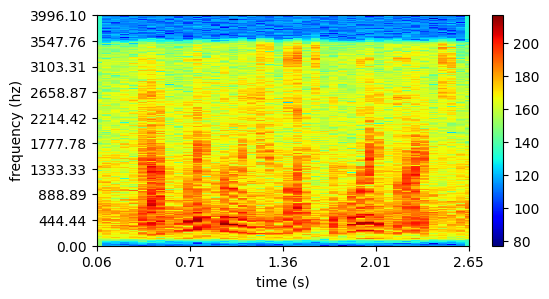

timebins:  42
freqbins:  513


<Figure size 640x480 with 0 Axes>

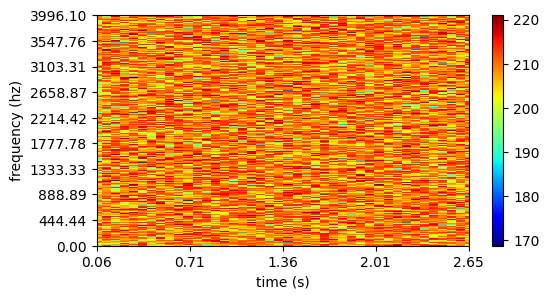

timebins:  42
freqbins:  513


<Figure size 640x480 with 0 Axes>

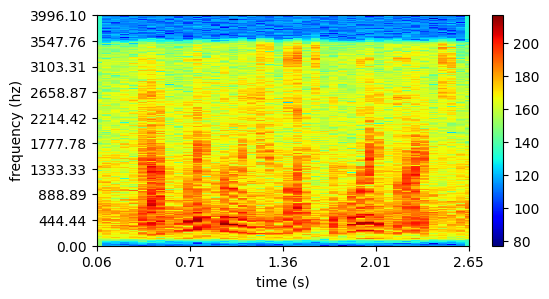

timebins:  42
freqbins:  513


<Figure size 640x480 with 0 Axes>

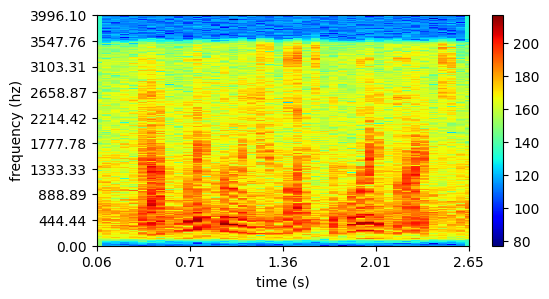

timebins:  43
freqbins:  513


<Figure size 640x480 with 0 Axes>

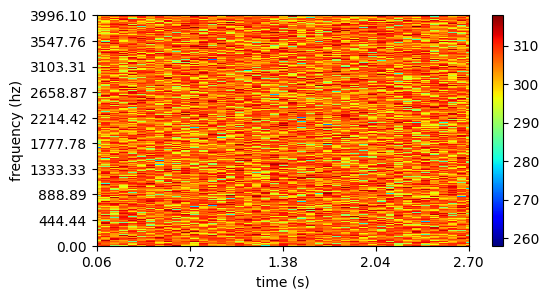

timebins:  43
freqbins:  513


<Figure size 640x480 with 0 Axes>

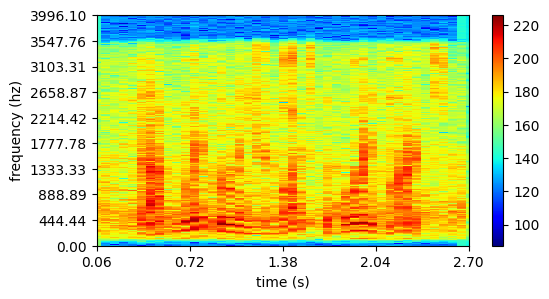

timebins:  42
freqbins:  513


<Figure size 640x480 with 0 Axes>

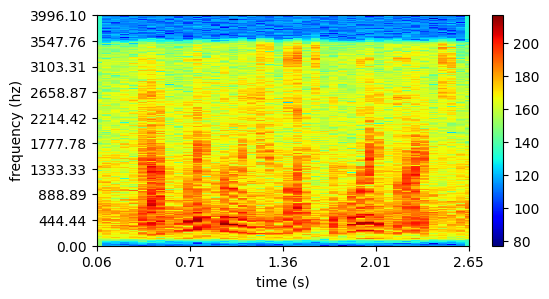

timebins:  42
freqbins:  513


<Figure size 640x480 with 0 Axes>

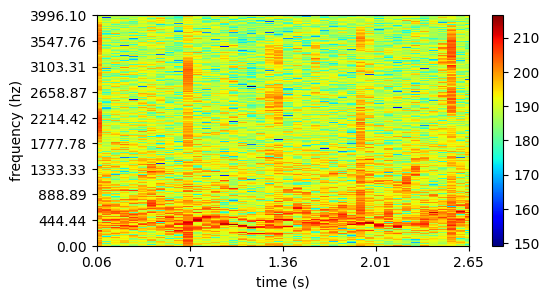

timebins:  42
freqbins:  513


<Figure size 640x480 with 0 Axes>

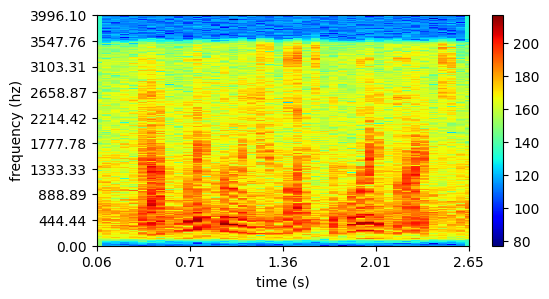

<Figure size 640x480 with 0 Axes>

In [19]:
org_base = ROOT / "dataset" / "test_sounds" / "test_sound"
i = 4
extension = ".wav"
enc_base = ROOT /"test1" / "test_encrypted" / "enc"
dec_base = ROOT /"test1" / "test_decrypted" / "dec"

path = (str(org_base) + str(i) + extension)
ims = spectogram(path)
path = (str(enc_base) + str(i) + extension)
ims = spectogram(path)
path = (str(dec_base) + str(i) + extension)
ims = spectogram(path)



enc_base = ROOT /"test2" / "test_encrypted" / "enc"
dec_base = ROOT /"test2" / "test_decrypted" / "dec"

path = (str(org_base) + str(i) + extension)
ims = spectogram(path)
path = (str(enc_base) + str(i) + extension)
ims = spectogram(path)
path = (str(dec_base) + str(i) + extension)
ims = spectogram(path)




enc_base = ROOT /"test4" / "test_encrypted" / "enc"
dec_base = ROOT /"test4" / "test_decrypted" / "dec"

path = (str(org_base) + str(i) + extension)
ims = spectogram(path)
path = (str(enc_base) + str(i) + extension)
ims = spectogram(path)
path = (str(dec_base) + str(i) + extension)
ims = spectogram(path)

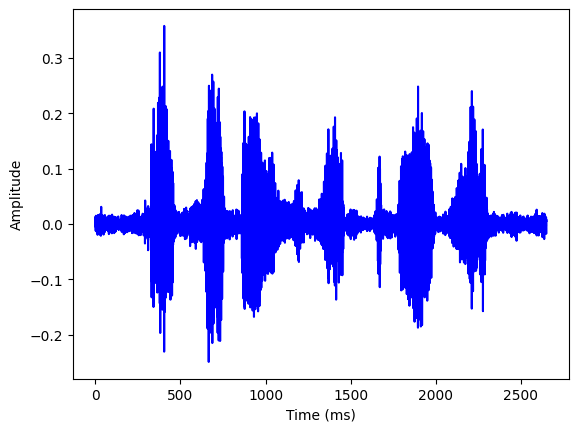

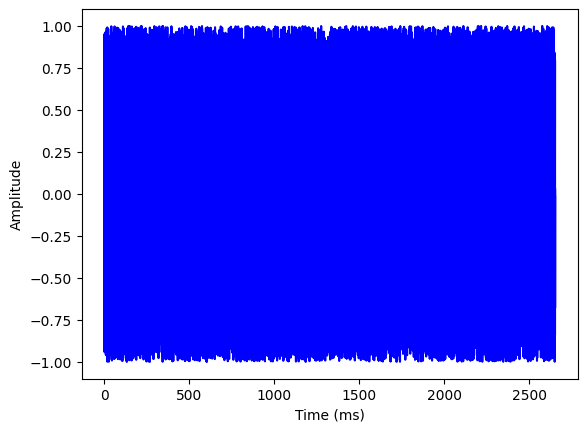

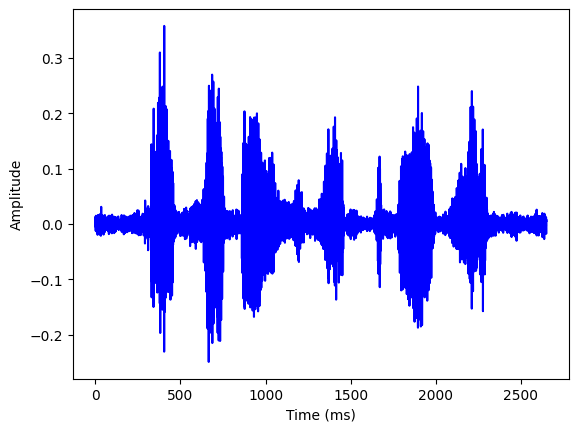

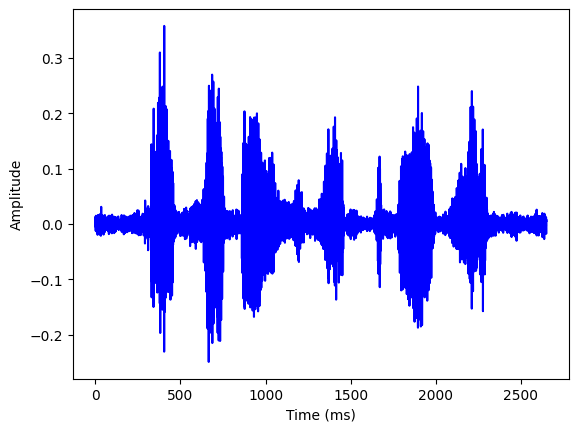

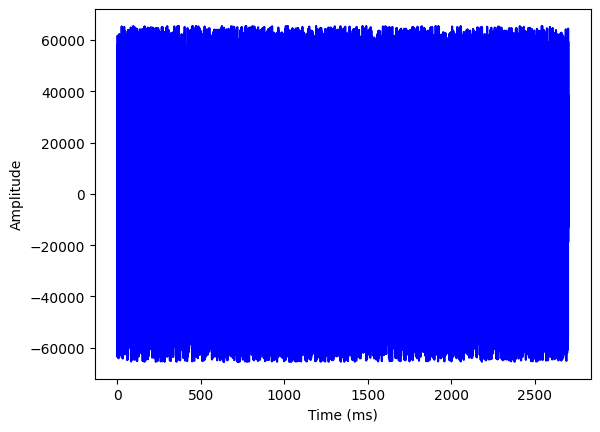

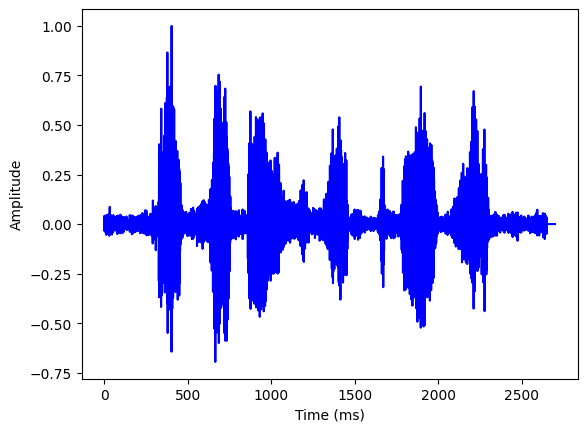

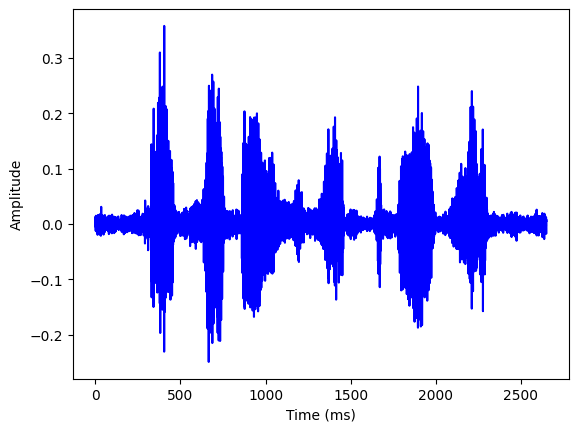

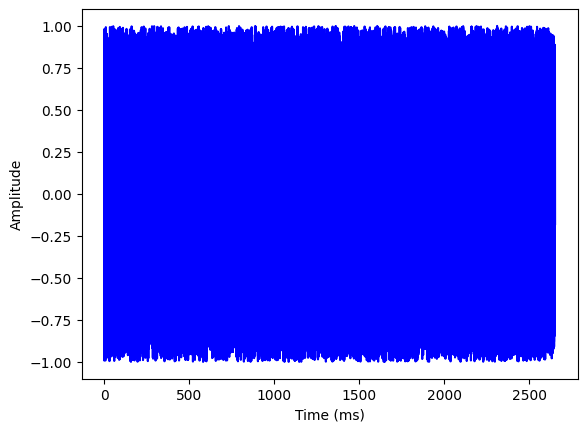

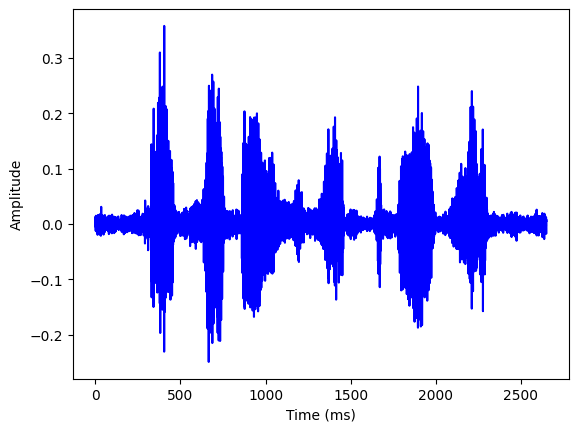

In [82]:
org_base = ROOT / "dataset" / "test_sounds" / "test_sound"
i = 4
extension = ".wav"
enc_base = ROOT /"test1" / "test_encrypted" / "enc"
dec_base = ROOT /"test1" / "test_decrypted" / "dec"

path = (str(org_base) + str(i) + extension)
ims = spectr(path)
path = (str(enc_base) + str(i) + extension)
ims = spectr(path)
path = (str(dec_base) + str(i) + extension)
ims = spectr(path)



enc_base = ROOT /"test2" / "test_encrypted" / "enc"
dec_base = ROOT /"test2" / "test_decrypted" / "dec"

path = (str(org_base) + str(i) + extension)
ims = spectr(path)
path = (str(enc_base) + str(i) + extension)
ims = spectr(path)
path = (str(dec_base) + str(i) + extension)
ims = spectr(path)




enc_base = ROOT /"test4" / "test_encrypted" / "enc"
dec_base = ROOT /"test4" / "test_decrypted" / "dec"

path = (str(org_base) + str(i) + extension)
ims = spectr(path)
path = (str(enc_base) + str(i) + extension)
ims = spectr(path)
path = (str(dec_base) + str(i) + extension)
ims = spectr(path)

## Sensetivity to key changes

test1

In [92]:
extension = ".wav"

org_base = ROOT / "dataset" / "test_sounds" / "test_sound"

i = 1
org = str(org_base.with_name(f"test_sound{i}{extension}"))

x0 = 0.1444
r = 0.9444

enc_base = ROOT / "test1" / "key_change" / "enc"
dec_base = ROOT / "test1" / "key_change" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
test1.script1.test_1_run(org, enc1, dec1, x0, r)

x1 = 0.1443

enc2 = str(enc_base.with_name(f"enc2{extension}"))
dec2 = str(dec_base.with_name(f"dec2{extension}"))
test1.script1.test_1_run(org, enc2, dec2, x1, r)



In [95]:
ber = get_ber(enc1, enc2)
print(ber)

0.5018792828449905


test2


In [97]:
extension = ".wav"

org_base = ROOT / "dataset" / "test_sounds" / "test_sound"

i = 1
org = str(org_base.with_name(f"test_sound{i}{extension}"))

secret1 = 4444
secret2 = 4445
secret3 = 4443

enc_base = ROOT / "test2" / "key_change" / "enc"
dec_base = ROOT / "test2" / "key_change" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
test2.script2.test_2_run(org, enc1, dec1, secret1, secret2, secret3)

secret2 = 4444

enc2 = str(enc_base.with_name(f"enc2{extension}"))
dec2 = str(dec_base.with_name(f"dec2{extension}"))
test2.script2.test_2_run(org, enc2, dec2, secret1, secret2, secret3)



[warn] input rate=8000, orig rate=48000
done
[warn] input rate=8000, orig rate=48000
done


In [98]:
ber = get_ber(enc1, enc2)
print(ber)

0.5024967447916666


test4


In [115]:
extension = ".wav"

org_base = ROOT / "dataset" / "test_sounds" / "test_sound"

i = 1
org = str(org_base.with_name(f"test_sound{i}{extension}"))

seed = 0.012444
r=3.9159

enc_base = ROOT / "test4" / "key_change" / "enc"
dec_base = ROOT / "test4" / "key_change" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
test4.script4.test_4_run(org, enc1, dec1, seed, r, True)

seed = 0.0188883
r=2.456

enc2 = str(enc_base.with_name(f"enc2{extension}"))
dec2 = str(dec_base.with_name(f"dec2{extension}"))
test4.script4.test_4_run(org, enc2, dec2, seed, r, True)



[key] not found, generating: test4/artefacts/key_u8.bin
[key] saved: test4/artefacts/key_u8.bin (10000 bytes)
Key length: 10000
Extract from input audio file
E:\labs\5 course\NearS\measures\dataset\test_sounds\test_sound1.wav
Written to file  E:\labs\5 course\NearS\measures\test4\key_change\enc1.wav
Now we write the values back into a audio file
Written to file  E:\labs\5 course\NearS\measures\test4\key_change\dec1.wav
[key] not found, generating: test4/artefacts/key_u8.bin
[key] saved: test4/artefacts/key_u8.bin (10000 bytes)
Key length: 10000
Extract from input audio file
E:\labs\5 course\NearS\measures\dataset\test_sounds\test_sound1.wav
Written to file  E:\labs\5 course\NearS\measures\test4\key_change\enc2.wav
Now we write the values back into a audio file
Written to file  E:\labs\5 course\NearS\measures\test4\key_change\dec2.wav


In [116]:
ber = get_ber(enc1, enc2)
print(ber)

0.5092930352079396


## Sensetivity to input change

In [130]:
org_base = ROOT / "dataset" / "changes_1_bit" / "test_sound"

i = 1
org = str(org_base.with_name(f"test_sound{i}{extension}"))
org_1bit = str(org_base.with_name(f"test_sound_bit_invert{i}{extension}"))

fs, bytes_1 = load_wav_bytes(org)
bytes_2 = bytes_1.copy()
bytes_2[0] ^= 0b00010000

save_wav_bytes((fs, bytes_2), org_1bit)

test1

In [131]:
extension = ".wav"

org_base = ROOT / "dataset" / "changes_1_bit" / "test_sound"

i = 1
org = str(org_base.with_name(f"test_sound{i}{extension}"))

enc_base = ROOT / "test1" / "bit_invert" / "enc"
dec_base = ROOT / "test1" / "bit_invert" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
test1.script1.test_1_run(org, enc1, dec1)


org = str(org_base.with_name(f"test_sound_bit_invert{i}{extension}"))

enc2 = str(enc_base.with_name(f"enc2{extension}"))
dec2 = str(dec_base.with_name(f"dec2{extension}"))
test1.script1.test_1_run(org, enc2, dec2)



In [132]:
ber = get_ber(enc1, enc2)
print(ber)

3.69210775047259e-06


test2

In [133]:
extension = ".wav"

org_base = ROOT / "dataset" / "changes_1_bit" / "test_sound"

i = 1
org = str(org_base.with_name(f"test_sound{i}{extension}"))

enc_base = ROOT / "test2" / "bit_invert" / "enc"
dec_base = ROOT / "test2" / "bit_invert" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
test2.script2.test_2_run(org, enc1, dec1)


org = str(org_base.with_name(f"test_sound_bit_invert{i}{extension}"))

enc2 = str(enc_base.with_name(f"enc2{extension}"))
dec2 = str(dec_base.with_name(f"dec2{extension}"))
test2.script2.test_2_run(org, enc2, dec2)



[warn] input rate=8000, orig rate=48000
done
[warn] input rate=8000, orig rate=48000
done


In [134]:
ber = get_ber(enc1, enc2)
print(ber)

1.6276041666666666e-05


test4

In [135]:
extension = ".wav"

org_base = ROOT / "dataset" / "changes_1_bit" / "test_sound"

i = 1
org = str(org_base.with_name(f"test_sound{i}{extension}"))

enc_base = ROOT / "test4" / "bit_invert" / "enc"
dec_base = ROOT / "test4" / "bit_invert" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
test4.script4.test_4_run(org, enc1, dec1)


org = str(org_base.with_name(f"test_sound_bit_invert{i}{extension}"))

enc2 = str(enc_base.with_name(f"enc2{extension}"))
dec2 = str(dec_base.with_name(f"dec2{extension}"))
test4.script4.test_4_run(org, enc2, dec2)



[key] loaded: test4/artefacts/key_u8.bin (10000 bytes)
Key length: 10000
Extract from input audio file
E:\labs\5 course\NearS\measures\dataset\changes_1_bit\test_sound1.wav
Written to file  E:\labs\5 course\NearS\measures\test4\bit_invert\enc1.wav
Now we write the values back into a audio file
Written to file  E:\labs\5 course\NearS\measures\test4\bit_invert\dec1.wav
[key] loaded: test4/artefacts/key_u8.bin (10000 bytes)
Key length: 10000
Extract from input audio file
E:\labs\5 course\NearS\measures\dataset\changes_1_bit\test_sound_bit_invert1.wav
Written to file  E:\labs\5 course\NearS\measures\test4\bit_invert\enc2.wav
Now we write the values back into a audio file
Written to file  E:\labs\5 course\NearS\measures\test4\bit_invert\dec2.wav


In [136]:
ber = get_ber(enc1, enc2)
print(ber)

3.69210775047259e-06


### нет лавинного эффекта из-за xor-шифрования (beer~0, при изменении 1 бита на входе, в шифротексте меняется 1 бит as well)

## Пропагация ошибки в шифротексте

In [141]:
i = 1
org_base = ROOT / "dataset" / "chipher_1_bit_error" / "test_sound"
org = str(org_base.with_name(f"test_sound{i}{extension}"))


enc_base = ROOT / "test1" / "chipher_1_bit_error" / "enc"
dec_base = ROOT / "test1" / "chipher_1_bit_error" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
enc2 = str(enc_base.with_name(f"enc_err1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))

test1.script1.test_1_run(org, enc1, dec1, errored_enc=enc2)

ruining


In [ ]:
# сравнение орига и дешифра
ber = get_ber(org, dec1)
print(ber)
# сравнение шифров. если около 0, то всрался 1 бит или очень мало битов
ber = get_ber(enc1, enc2)
print(ber)

3.69210775047259e-06
3.69210775047259e-06


то есть 1 бит всрался в шифре при передаче = 1 бит всрётся при дешифровке. Устойчивость к помехам, получается

test2

In [152]:
i = 1
org_base = ROOT / "dataset" / "chipher_1_bit_error" / "test_sound"
org = str(org_base.with_name(f"test_sound{i}{extension}"))


secret1 = 4444
secret2 = 4445
secret3 = 4443

enc_base = ROOT / "test2" / "chipher_1_bit_error" / "enc"
dec_base = ROOT / "test2" / "chipher_1_bit_error" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
enc2 = str(enc_base.with_name(f"enc_err1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
test2.script2.test_2_run(org, enc1, dec1, secret1, secret2, secret3, errored_enc=enc2)

dec2 = str(dec_base.with_name(f"dec2{extension}"))
test2.script2.test_2_run(org, enc1, dec2, secret1, secret2, secret3)


[warn] input rate=8000, orig rate=48000
done
[warn] input rate=8000, orig rate=48000
done


In [ ]:
# сравнение орига и дешифра. если около 0, то всрался 1 бит или очень мало битов, если 0.3, то треть всралась
ber = get_ber(org, dec1)
print(ber)
# ориг и дешифр БЕЗ внесения ошибки в шифротекст
ber = get_ber(org, dec2)
print(ber)
# дешифр БЕЗ внесения ошибки в шифротекст и дешифр С ВНЕСЕНИЕМ ошибки в шифротекст
ber = get_ber(dec1, dec2)
print(ber)
# сравнение шифров. если около 0, то всрался 1 бит или очень мало битов
ber = get_ber(enc1, enc2)
print(ber)

0.31688622400756145
0.3302922672495274
0.32394856770833336
3.2552083333333335e-06


тут уже посильнее всрался дешифр по сравнению с оригиналом, но мб из-за корреляции 0,7 в начале, мб просто восстанавливает хреноватенько

test4

In [147]:
i = 1
org_base = ROOT / "dataset" / "chipher_1_bit_error" / "test_sound"
org = str(org_base.with_name(f"test_sound{i}{extension}"))


enc_base = ROOT / "test4" / "chipher_1_bit_error" / "enc"
dec_base = ROOT / "test4" / "chipher_1_bit_error" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
enc2 = str(enc_base.with_name(f"enc_err1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))

test4.script4.test_4_run(org, enc1, dec1, errored_enc=enc2)

[key] loaded: test4/artefacts/key_u8.bin (10000 bytes)
Key length: 10000
Extract from input audio file
E:\labs\5 course\NearS\measures\dataset\chipher_1_bit_error\test_sound1.wav
Written to file  E:\labs\5 course\NearS\measures\test4\chipher_1_bit_error\enc1.wav
Now we write the values back into a audio file
Written to file  E:\labs\5 course\NearS\measures\test4\chipher_1_bit_error\dec1.wav


In [148]:
# сравнение орига и дешифра. если около 0, то всрался 1 бит или очень мало битов, если 0.3, то треть всралась
ber = get_ber(org, dec1)
print(ber)
# сравнение шифров. если около 0, то всрался 1 бит или очень мало битов
ber = get_ber(enc1, enc2)
print(ber)

3.69210775047259e-06
3.69210775047259e-06


## ТЕСТ КОВЕРТАЦИИ В ДРУГИЕ ФОРМАТЫ ШИФРОТЕКСТА ПРИ ПЕРЕДАЧЕ

test1

In [165]:
i = 1
org_base = ROOT / "dataset" / "chipher_1_bit_error" / "test_sound"
org = str(org_base.with_name(f"test_sound{i}{extension}"))


enc_base = ROOT / "test1" / "convertations" / "enc"
dec_base = ROOT / "test1" / "convertations" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
org_format = "wav"
new_format = "mp3"

test1.script1.test_1_run(org, enc1, dec1, org_format=org_format, new_format=new_format)
ber = get_ber(org, dec1)
print(ber)

0.4852721821833648


test2

In [ ]:
i = 1
org_base = ROOT / "dataset" / "chipher_1_bit_error" / "test_sound"
org = str(org_base.with_name(f"test_sound{i}{extension}"))


enc_base = ROOT / "test2" / "convertations" / "enc"
dec_base = ROOT / "test2" / "convertations" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
org_format = "wav"
new_format = "mp3"

test2.script2.test_2_run(org, enc1, dec1, org_format=org_format, new_format=new_format)
ber = get_ber(org, dec1)
print(ber)

[warn] input rate=8000, orig rate=48000
done
0.48521680056710775


test4

In [ ]:
i = 1
org_base = ROOT / "dataset" / "chipher_1_bit_error" / "test_sound"
org = str(org_base.with_name(f"test_sound{i}{extension}"))


enc_base = ROOT / "test4" / "convertations" / "enc"
dec_base = ROOT / "test4" / "convertations" / "dec"
enc1 = str(enc_base.with_name(f"enc1{extension}"))
dec1 = str(dec_base.with_name(f"dec1{extension}"))
org_format = "wav"
new_format = "mp3"

test4.script4.test_4_run(org, enc1, dec1, org_format=org_format, new_format=new_format)
ber = get_ber(org, dec1)
print(ber)

[key] loaded: test4/artefacts/key_u8.bin (10000 bytes)
Key length: 10000
Extract from input audio file
E:\labs\5 course\NearS\measures\dataset\chipher_1_bit_error\test_sound1.wav
Written to file  E:\labs\5 course\NearS\measures\test4\convertations\enc1.wav
Now we write the values back into a audio file
Written to file  E:\labs\5 course\NearS\measures\test4\convertations\dec1.wav
0.4043079513232514


ber такой низкий из-за того что mp3 теряет данные при преобразовании в него